# Technical Assignment — Comprehensive EDA Notebook

This notebook is focused on **pattern discovery** from multiple angles:

1. Device-wise behavior
2. Location-wise traffic patterns
3. Temporal patterns
4. Movement/journey patterns
5. Signal/data-quality patterns
6. Anomaly context overlays

It supports two run modes:

- **Fast mode**: load precomputed outputs and cached EDA aggregates
- **Build mode**: recompute additional EDA aggregates directly from raw session data

In [21]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)
plt.style.use("ggplot")

In [22]:
WORKSPACE_ROOT = Path("/Users/zohaibsarwar/Assignment Folder")
OUTPUT_DIR = WORKSPACE_ROOT / "outputs"

SESSION_CSV = Path("/Users/zohaibsarwar/Downloads/allunite_device_session.csv")
FACILITY_CSV = Path("/Users/zohaibsarwar/Downloads/facility_information - Sheet1.csv")

# Fast path by default. Set to True if you want to rebuild EDA-specific aggregates.
BUILD_RAW_EDA_AGGREGATES = False

for p in [OUTPUT_DIR, SESSION_CSV, FACILITY_CSV]:
    print(f"{p}: {'FOUND' if p.exists() else 'MISSING'}")

/Users/zohaibsarwar/Assignment Folder/outputs: FOUND
/Users/zohaibsarwar/Downloads/allunite_device_session.csv: FOUND
/Users/zohaibsarwar/Downloads/facility_information - Sheet1.csv: FOUND


In [23]:
# Core outputs from the analysis pipeline.
hourly_footfall = pd.read_csv(OUTPUT_DIR / "task1_hourly_estimated_footfall.csv", parse_dates=["hour_start"])
pair_counts = pd.read_csv(OUTPUT_DIR / "task2_sensor_overlap_pairs.csv")
top_paths = pd.read_csv(OUTPUT_DIR / "task3_top_journeys.csv")
transitions = pd.read_csv(OUTPUT_DIR / "task3_transition_matrix.csv")
anomaly_comparison_df = pd.read_csv(OUTPUT_DIR / "task4_anomaly_comparison.csv", parse_dates=["hour_start"])
benchmark_df = pd.read_csv(OUTPUT_DIR / "task4_method_benchmark.csv")
overlap_df = pd.read_csv(OUTPUT_DIR / "task4_method_overlap_jaccard.csv", index_col=0)

facilities = pd.read_csv(FACILITY_CSV)
facility_lookup = facilities[["facility_num", "facility_name", "latitude", "longitude"]].drop_duplicates()

hourly_footfall = hourly_footfall.merge(facility_lookup[["facility_num", "facility_name"]], on="facility_num", how="left")
anomaly_comparison_df = anomaly_comparison_df.merge(
    facility_lookup[["facility_num", "facility_name"]], on="facility_num", how="left"
)

print("Loaded core output tables.")
print("hourly_footfall rows:", len(hourly_footfall))
print("anomaly_comparison rows:", len(anomaly_comparison_df))

Loaded core output tables.
hourly_footfall rows: 1451
anomaly_comparison rows: 1451


## EDA Aggregate Loader (fast cache + optional rebuild)

The notebook uses two EDA aggregate caches:

- `outputs/eda_device_profile.csv`
- `outputs/eda_facility_hour_quality.csv`

If `BUILD_RAW_EDA_AGGREGATES = True`, these are recomputed from raw sessions and overwritten.

In [24]:
device_profile_cache = OUTPUT_DIR / "eda_device_profile.csv"
facility_hour_quality_cache = OUTPUT_DIR / "eda_facility_hour_quality.csv"

def build_eda_aggregates_from_raw() -> tuple[pd.DataFrame, pd.DataFrame]:
    usecols = [
        "session_start",
        "device_id",
        "facility_num",
        "session_duration",
        "signal_level",
        "is_permanent_device",
        "is_local",
        "is_trusted",
        "is_excluded",
        "is_anomaly",
        "is_fake",
    ]
    s = pd.read_csv(SESSION_CSV, usecols=usecols, parse_dates=["session_start"], low_memory=False)
    if s["session_start"].dt.tz is None:
        s["session_start"] = s["session_start"].dt.tz_localize("UTC")

    for col in ["is_permanent_device", "is_local", "is_trusted", "is_excluded", "is_anomaly", "is_fake"]:
        s[col] = s[col].astype("boolean").fillna(False).astype(bool)

    s["hour_start"] = s["session_start"].dt.floor("h")
    s["date"] = s["session_start"].dt.date
    s["hour_of_day"] = s["session_start"].dt.hour
    s["is_flagged"] = s[["is_permanent_device", "is_excluded", "is_anomaly", "is_fake"]].any(axis=1)

    device_profile = (
        s.groupby("device_id", as_index=False)
        .agg(
            total_sessions=("device_id", "size"),
            unique_facilities=("facility_num", "nunique"),
            active_days=("date", "nunique"),
            night_sessions=("hour_of_day", lambda x: int((x <= 5).sum())),
            trusted_sessions=("is_trusted", "sum"),
            local_sessions=("is_local", "sum"),
            flagged_sessions=("is_flagged", "sum"),
            mean_session_duration=("session_duration", "mean"),
            mean_signal_level=("signal_level", "mean"),
            first_seen=("session_start", "min"),
            last_seen=("session_start", "max"),
        )
    )
    device_profile["night_ratio"] = device_profile["night_sessions"] / device_profile["total_sessions"]
    device_profile["trusted_ratio"] = device_profile["trusted_sessions"] / device_profile["total_sessions"]
    device_profile["local_ratio"] = device_profile["local_sessions"] / device_profile["total_sessions"]
    device_profile["flagged_ratio"] = device_profile["flagged_sessions"] / device_profile["total_sessions"]

    facility_hour_quality = (
        s.groupby(["facility_num", "hour_start"], as_index=False)
        .agg(
            total_sessions=("device_id", "size"),
            unique_devices=("device_id", "nunique"),
            mean_signal_level=("signal_level", "mean"),
            median_session_duration=("session_duration", "median"),
            trusted_ratio=("is_trusted", "mean"),
            local_ratio=("is_local", "mean"),
            flagged_rate=("is_flagged", "mean"),
        )
    )

    device_profile.to_csv(device_profile_cache, index=False)
    facility_hour_quality.to_csv(facility_hour_quality_cache, index=False)
    return device_profile, facility_hour_quality

if BUILD_RAW_EDA_AGGREGATES or not (device_profile_cache.exists() and facility_hour_quality_cache.exists()):
    device_profile, facility_hour_quality = build_eda_aggregates_from_raw()
else:
    device_profile = pd.read_csv(device_profile_cache, parse_dates=["first_seen", "last_seen"])
    facility_hour_quality = pd.read_csv(facility_hour_quality_cache, parse_dates=["hour_start"])

facility_hour_quality = facility_hour_quality.merge(
    facility_lookup[["facility_num", "facility_name"]], on="facility_num", how="left"
)

print("Loaded EDA aggregate tables.")
print("device_profile rows:", len(device_profile))
print("facility_hour_quality rows:", len(facility_hour_quality))

Loaded EDA aggregate tables.
device_profile rows: 2043833
facility_hour_quality rows: 1451


## Device-Wise EDA

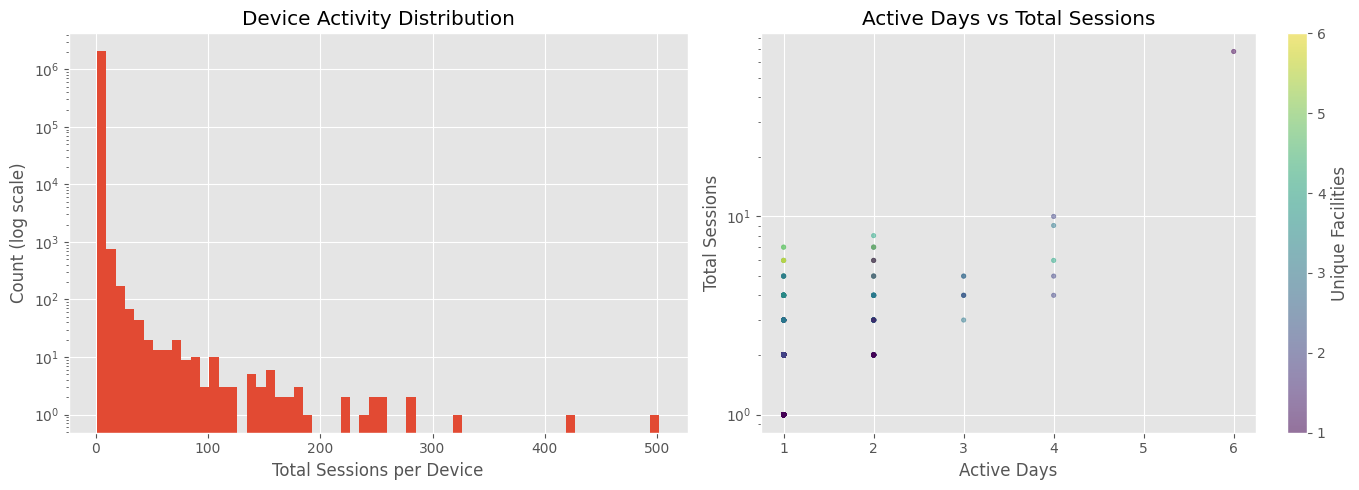

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Long-tail activity profile
axes[0].hist(device_profile["total_sessions"], bins=60, log=True)
axes[0].set_title("Device Activity Distribution")
axes[0].set_xlabel("Total Sessions per Device")
axes[0].set_ylabel("Count (log scale)")

# Repeat vs occasional behavior
sample_n = min(15000, len(device_profile))
dev_sample = device_profile.sample(sample_n, random_state=42)
sc = axes[1].scatter(
    dev_sample["active_days"],
    dev_sample["total_sessions"],
    c=dev_sample["unique_facilities"],
    s=10,
    alpha=0.5,
)
axes[1].set_title("Active Days vs Total Sessions")
axes[1].set_xlabel("Active Days")
axes[1].set_ylabel("Total Sessions")
axes[1].set_yscale("log")
plt.colorbar(sc, ax=axes[1], label="Unique Facilities")

plt.tight_layout()
plt.show()

Top devices by total sessions:


,device_id,total_sessions,active_days,unique_facilities,night_ratio,flagged_ratio
620422,-3619534240744592682,502,7,8,0.059761,0.001992
1758209,6648128703961333840,421,7,9,0.451306,1.000000
741803,-2525058596647437065,321,7,9,0.383178,1.000000
1896146,7889853623475887126,281,5,9,0.409253,1.000000
1600666,5221751847408166251,281,6,8,0.000000,1.000000
709485,-2816337548021635381,258,7,3,0.236434,1.000000
1876129,7709270161714158097,255,6,9,0.509804,1.000000
446132,-5192221066165507185,250,6,9,0.000000,1.000000
301405,-6494026690822609217,250,7,2,0.304000,0.000000
1126948,956862762278954740,238,5,9,0.000000,1.000000


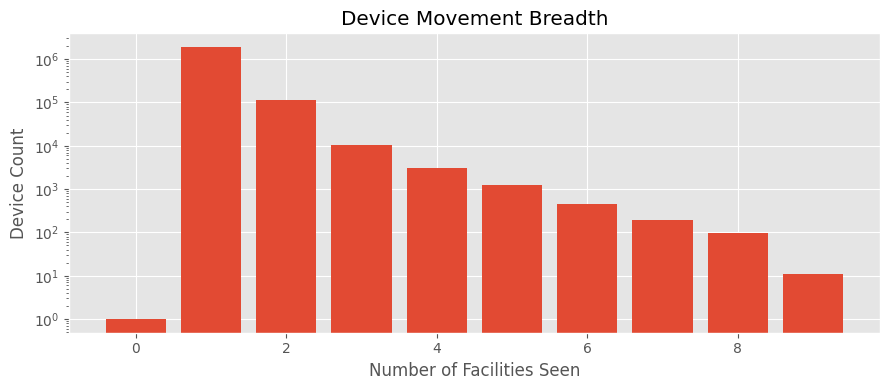

,unique_facilities,device_count
0,0,1
1,1,1912145
2,2,116003
3,3,10587
4,4,3085
5,5,1259
6,6,448
7,7,195
8,8,99
9,9,11


In [26]:
print("Top devices by total sessions:")
display(
    device_profile.sort_values("total_sessions", ascending=False)
    .head(20)[
        [
            "device_id",
            "total_sessions",
            "active_days",
            "unique_facilities",
            "night_ratio",
            "flagged_ratio",
        ]
    ]
)

facility_breadth = (
    device_profile["unique_facilities"].value_counts().sort_index().rename_axis("unique_facilities").reset_index(name="device_count")
)
plt.figure(figsize=(9, 4))
plt.bar(facility_breadth["unique_facilities"], facility_breadth["device_count"])
plt.title("Device Movement Breadth")
plt.xlabel("Number of Facilities Seen")
plt.ylabel("Device Count")
plt.yscale("log")
plt.tight_layout()
plt.show()

facility_breadth.head(10)

## Location-Wise EDA

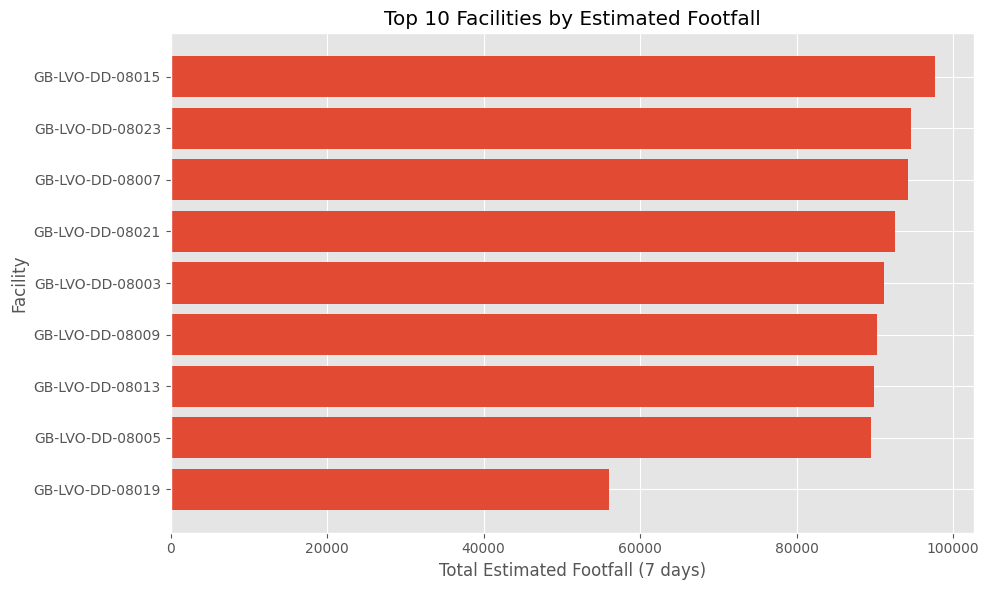

,facility_num,facility_name,estimated_total_footfall
5,66336,GB-LVO-DD-08015,97758.31
8,66342,GB-LVO-DD-08023,94638.27
2,66332,GB-LVO-DD-08007,94267.07
7,66340,GB-LVO-DD-08021,92599.02
0,66330,GB-LVO-DD-08003,91132.80
3,66333,GB-LVO-DD-08009,90277.81
4,66335,GB-LVO-DD-08013,89915.78
1,66331,GB-LVO-DD-08005,89483.36
6,66338,GB-LVO-DD-08019,55991.14


In [27]:
facility_totals = (
    hourly_footfall.groupby(["facility_num", "facility_name"], as_index=False)["estimated_total_footfall"]
    .sum()
    .sort_values("estimated_total_footfall", ascending=False)
)

plt.figure(figsize=(10, 6))
plot_tot = facility_totals.head(10).sort_values("estimated_total_footfall")
plt.barh(plot_tot["facility_name"], plot_tot["estimated_total_footfall"])
plt.title("Top 10 Facilities by Estimated Footfall")
plt.xlabel("Total Estimated Footfall (7 days)")
plt.ylabel("Facility")
plt.tight_layout()
plt.show()

facility_totals.head(10)

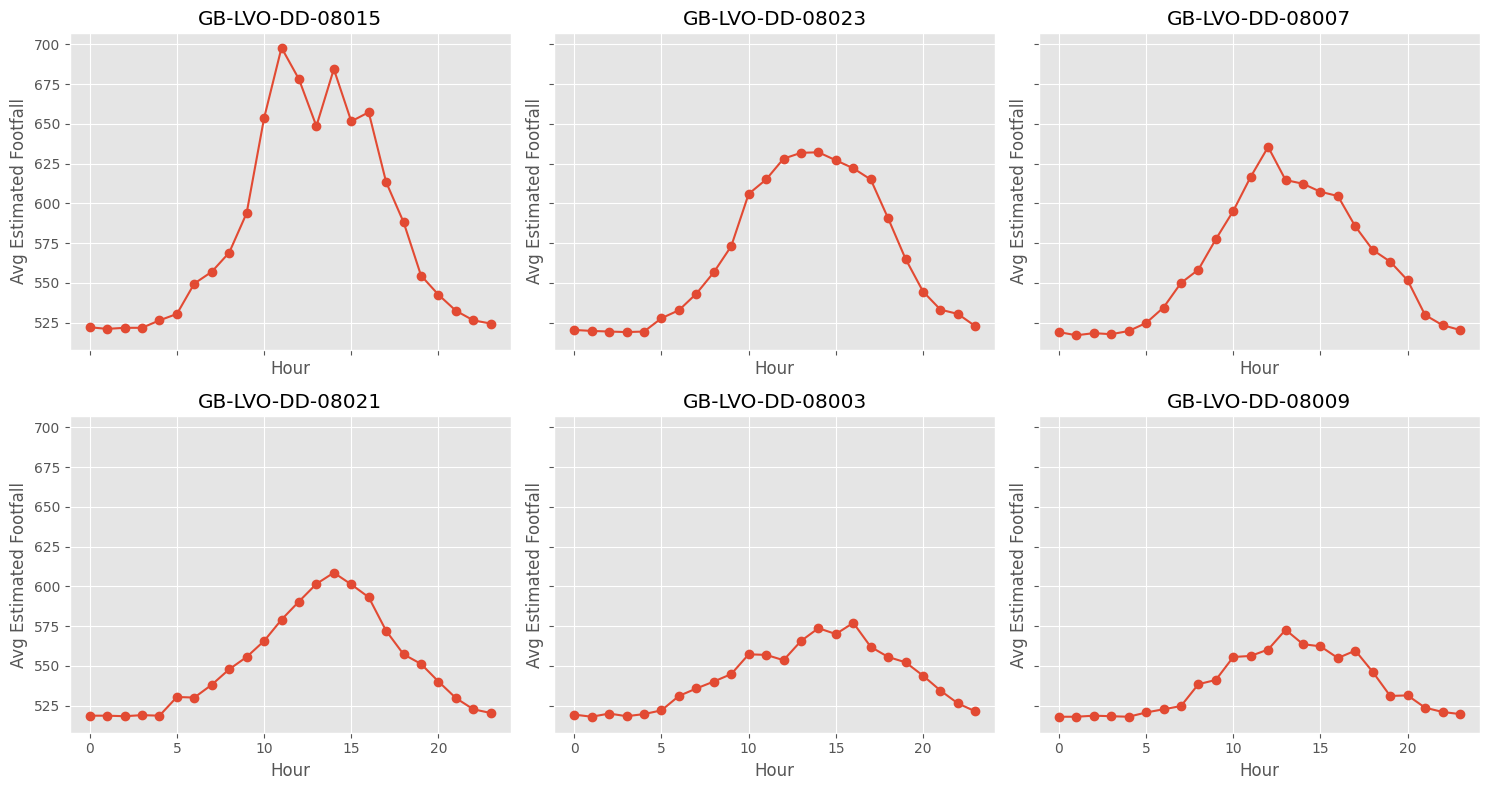

/var/folders/g_/1979vpb127z7y9jtbplxm61r0000gn/T/ipykernel_57005/672695317.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(series_for_box, labels=order, showfliers=False)


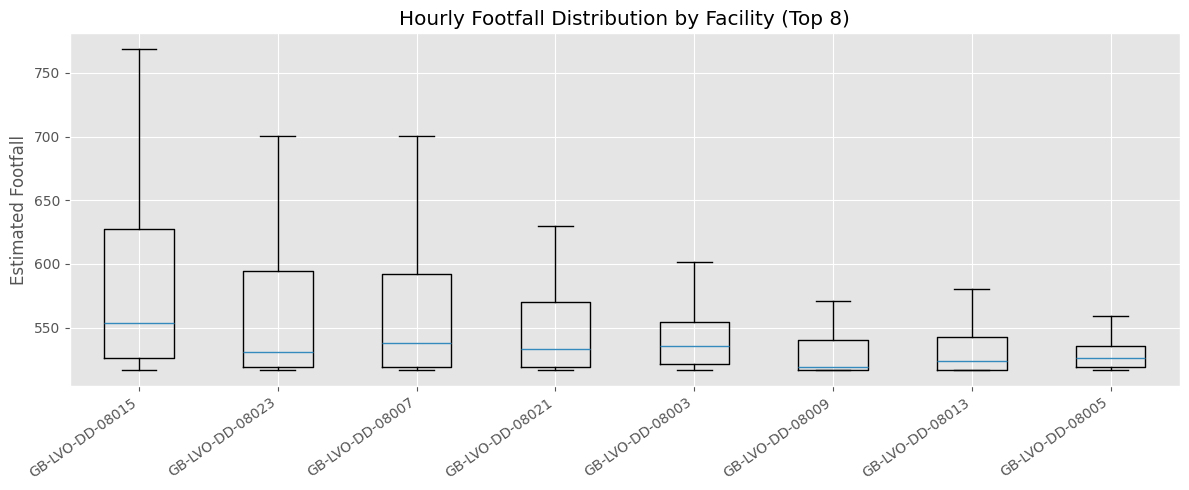

In [28]:
hourly_profile = hourly_footfall.copy()
hourly_profile["hour"] = hourly_profile["hour_start"].dt.hour
avg_hourly = (
    hourly_profile.groupby(["facility_name", "hour"], as_index=False)["estimated_total_footfall"].mean()
)

top_facilities = facility_totals.head(6)["facility_name"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for ax, name in zip(axes.flatten(), top_facilities):
    d = avg_hourly.loc[avg_hourly["facility_name"] == name].sort_values("hour")
    ax.plot(d["hour"], d["estimated_total_footfall"], marker="o", linewidth=1.5)
    ax.set_title(name)
    ax.set_xlabel("Hour")
    ax.set_ylabel("Avg Estimated Footfall")
for ax in axes.flatten()[len(top_facilities):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Distribution comparison by facility (top 8)
box_df = hourly_footfall.loc[hourly_footfall["facility_name"].isin(facility_totals.head(8)["facility_name"])].copy()
order = facility_totals.head(8)["facility_name"].tolist()
series_for_box = [box_df.loc[box_df["facility_name"] == nm, "estimated_total_footfall"] for nm in order]

plt.figure(figsize=(12, 5))
plt.boxplot(series_for_box, labels=order, showfliers=False)
plt.title("Hourly Footfall Distribution by Facility (Top 8)")
plt.xticks(rotation=35, ha="right")
plt.ylabel("Estimated Footfall")
plt.tight_layout()
plt.show()

## Temporal Pattern EDA

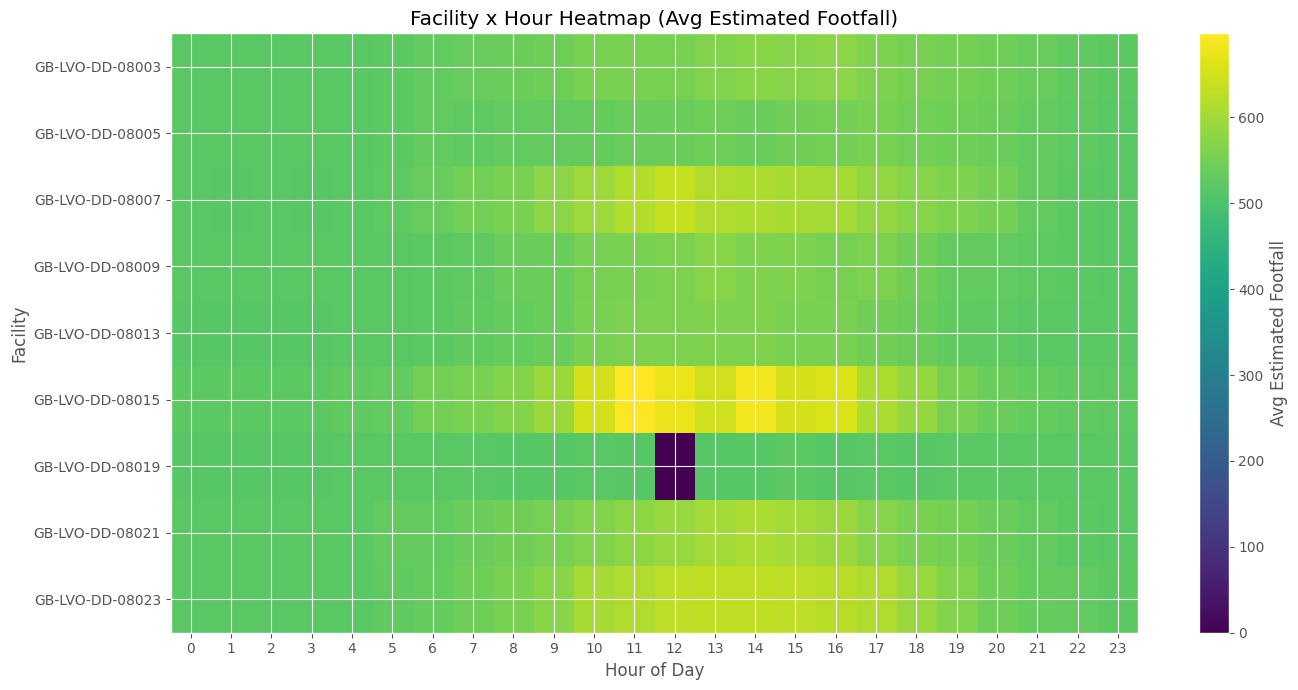

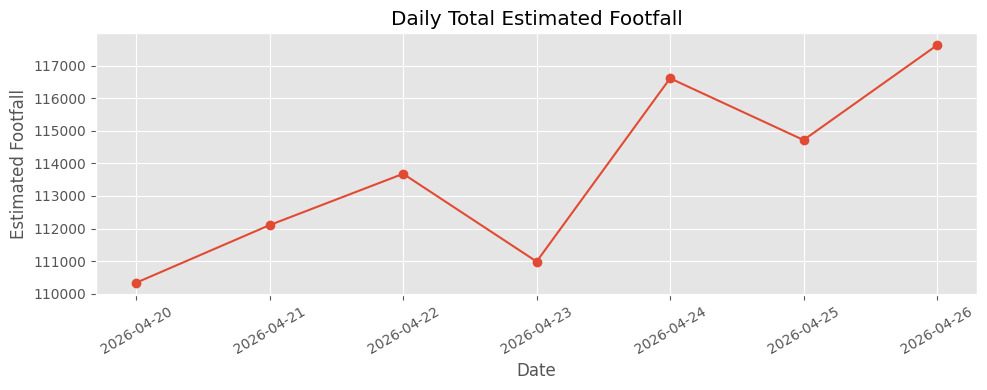

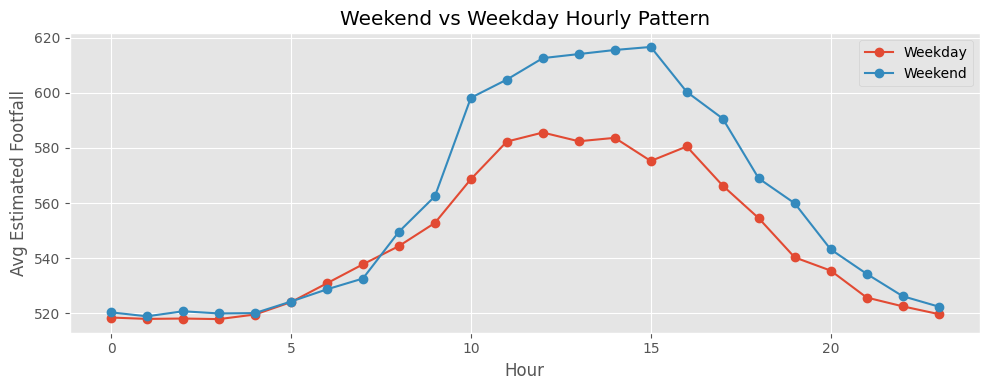

In [29]:
tmp = hourly_footfall.copy()
tmp["hour"] = tmp["hour_start"].dt.hour
tmp["date"] = tmp["hour_start"].dt.date
tmp["is_weekend"] = tmp["hour_start"].dt.dayofweek >= 5

heat = (
    tmp.groupby(["facility_name", "hour"], as_index=False)["estimated_total_footfall"]
    .mean()
    .pivot(index="facility_name", columns="hour", values="estimated_total_footfall")
)

plt.figure(figsize=(14, 7))
plt.imshow(heat.fillna(0).to_numpy(dtype=float), aspect="auto")
plt.title("Facility x Hour Heatmap (Avg Estimated Footfall)")
plt.xlabel("Hour of Day")
plt.ylabel("Facility")
plt.xticks(range(24), range(24))
plt.yticks(range(len(heat.index)), heat.index)
plt.colorbar(label="Avg Estimated Footfall")
plt.tight_layout()
plt.show()

# Overall day trend
by_day = tmp.groupby("date", as_index=False)["estimated_total_footfall"].sum()
plt.figure(figsize=(10, 4))
plt.plot(by_day["date"], by_day["estimated_total_footfall"], marker="o")
plt.title("Daily Total Estimated Footfall")
plt.xlabel("Date")
plt.ylabel("Estimated Footfall")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Weekend vs weekday hourly pattern
weekpart = (
    tmp.groupby(["is_weekend", "hour"], as_index=False)["estimated_total_footfall"].mean()
)
plt.figure(figsize=(10, 4))
for flag, grp in weekpart.groupby("is_weekend"):
    lbl = "Weekend" if flag else "Weekday"
    plt.plot(grp["hour"], grp["estimated_total_footfall"], marker="o", label=lbl)
plt.title("Weekend vs Weekday Hourly Pattern")
plt.xlabel("Hour")
plt.ylabel("Avg Estimated Footfall")
plt.legend()
plt.tight_layout()
plt.show()

,facility_name,peak_hour,mean_hourly_footfall,std_hourly_footfall
5,GB-LVO-DD-08015,11,697.888571,70.304007
2,GB-LVO-DD-08007,12,635.457143,71.040179
8,GB-LVO-DD-08023,14,632.102857,101.176163
7,GB-LVO-DD-08021,14,608.607143,58.676755
0,GB-LVO-DD-08003,16,577.055714,43.466445
3,GB-LVO-DD-08009,13,572.694286,64.665277
4,GB-LVO-DD-08013,14,561.951429,33.268666
1,GB-LVO-DD-08005,17,556.244286,40.004767
6,GB-LVO-DD-08019,15,523.240000,5.908739


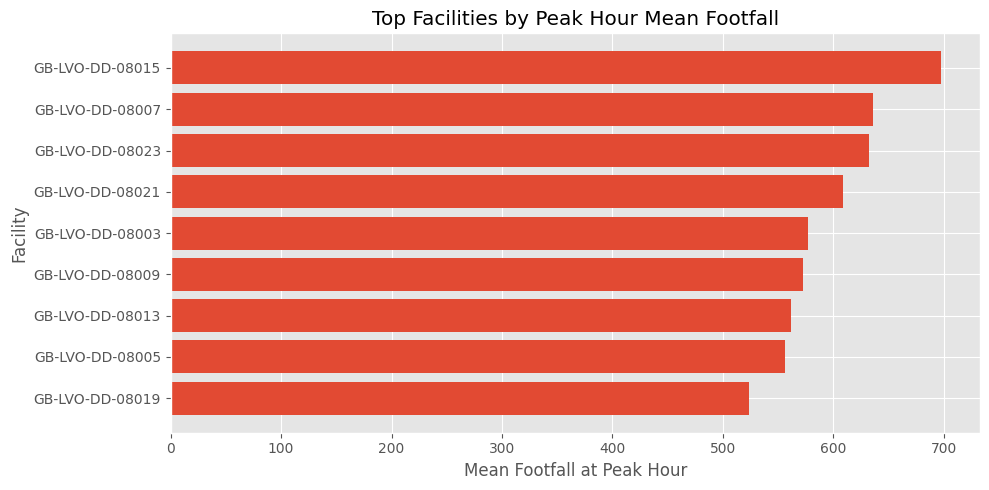

In [30]:
# Peak hour and variability summary per facility
hourly_stats = (
    tmp.groupby(["facility_num", "facility_name", "hour"], as_index=False)
    .agg(
        mean_hourly_footfall=("estimated_total_footfall", "mean"),
        std_hourly_footfall=("estimated_total_footfall", "std"),
    )
)

peak_rows = (
    hourly_stats.sort_values(["facility_name", "mean_hourly_footfall"], ascending=[True, False])
    .groupby("facility_name", as_index=False)
    .first()
    .sort_values("mean_hourly_footfall", ascending=False)
)

display(
    peak_rows[[
        "facility_name",
        "hour",
        "mean_hourly_footfall",
        "std_hourly_footfall",
    ]].rename(columns={"hour": "peak_hour"}).head(10)
)

plt.figure(figsize=(10, 5))
plot_peak = peak_rows.head(10).sort_values("mean_hourly_footfall")
plt.barh(plot_peak["facility_name"], plot_peak["mean_hourly_footfall"])
plt.title("Top Facilities by Peak Hour Mean Footfall")
plt.xlabel("Mean Footfall at Peak Hour")
plt.ylabel("Facility")
plt.tight_layout()
plt.show()

## Movement and Journey EDA

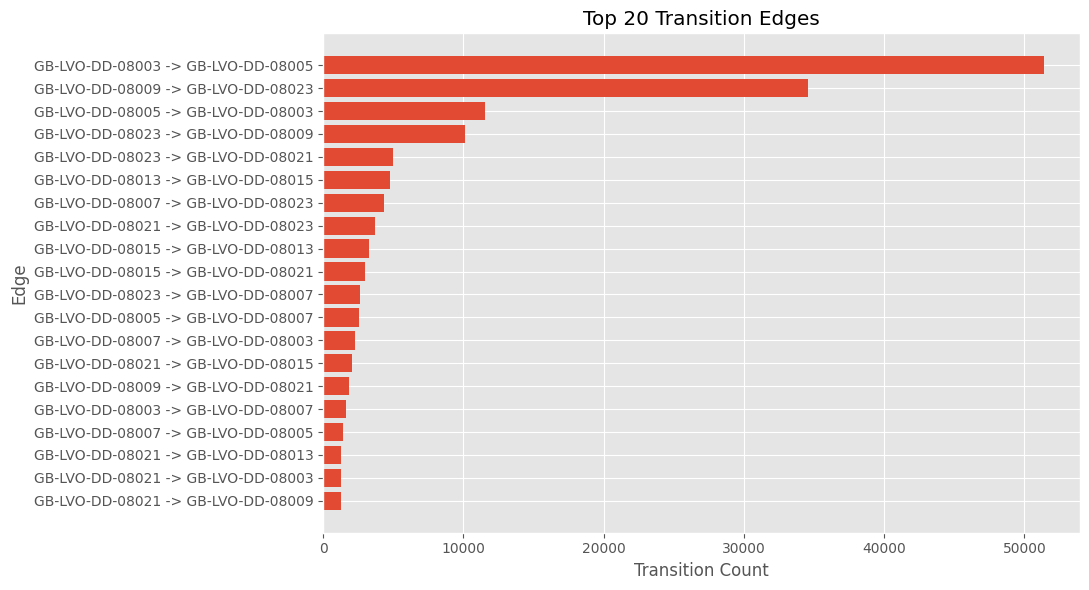

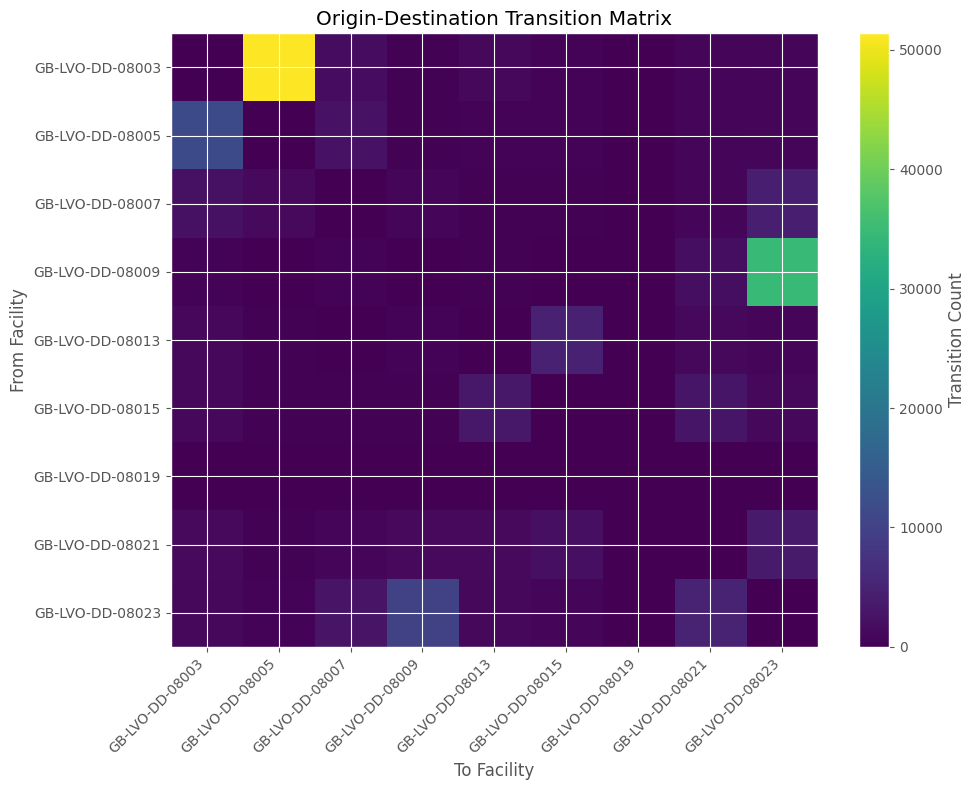

,facility_name_from,facility_name_to,transition_count
0,GB-LVO-DD-08003,GB-LVO-DD-08005,51395
1,GB-LVO-DD-08009,GB-LVO-DD-08023,34547
2,GB-LVO-DD-08005,GB-LVO-DD-08003,11532
3,GB-LVO-DD-08023,GB-LVO-DD-08009,10090
4,GB-LVO-DD-08023,GB-LVO-DD-08021,4954
5,GB-LVO-DD-08013,GB-LVO-DD-08015,4775
6,GB-LVO-DD-08007,GB-LVO-DD-08023,4340
7,GB-LVO-DD-08021,GB-LVO-DD-08023,3674
8,GB-LVO-DD-08015,GB-LVO-DD-08013,3299
9,GB-LVO-DD-08015,GB-LVO-DD-08021,2990


In [31]:
top_trans = transitions.sort_values("transition_count", ascending=False).head(20).copy()
top_trans["edge"] = top_trans["facility_name_from"] + " -> " + top_trans["facility_name_to"]

plt.figure(figsize=(11, 6))
plt.barh(top_trans.sort_values("transition_count")["edge"], top_trans.sort_values("transition_count")["transition_count"])
plt.title("Top 20 Transition Edges")
plt.xlabel("Transition Count")
plt.ylabel("Edge")
plt.tight_layout()
plt.show()

od = (
    transitions.pivot_table(
        index="facility_name_from",
        columns="facility_name_to",
        values="transition_count",
        aggfunc="sum",
        fill_value=0,
    )
)

plt.figure(figsize=(10, 8))
plt.imshow(od.to_numpy(dtype=float), aspect="auto")
plt.title("Origin-Destination Transition Matrix")
plt.xlabel("To Facility")
plt.ylabel("From Facility")
plt.xticks(range(len(od.columns)), od.columns, rotation=45, ha="right")
plt.yticks(range(len(od.index)), od.index)
plt.colorbar(label="Transition Count")
plt.tight_layout()
plt.show()

display(top_trans[["facility_name_from", "facility_name_to", "transition_count"]])

,path,device_count,path_length
0,66330 -> 66331,42826,2
1,66333 -> 66342,30510,2
2,66331 -> 66330,7212,2
3,66342 -> 66333,6898,2
4,66335 -> 66336,2964,2
5,66332 -> 66342,2778,2
6,66342 -> 66340,2534,2
7,66336 -> 66335,1730,2
8,66340 -> 66342,1626,2
9,66336 -> 66340,1529,2


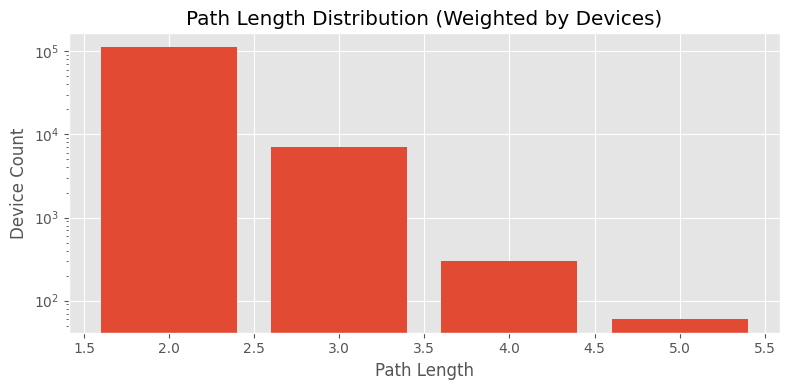

,path_length,device_count
0,2,112725
1,3,7010
2,4,298
3,5,60


In [32]:
# Common journey templates and path-length patterns
display(top_paths.head(20))

if "path_length" in top_paths.columns:
    length_dist = (
        top_paths.groupby("path_length", as_index=False)["device_count"].sum()
        .sort_values("path_length")
    )
    plt.figure(figsize=(8, 4))
    plt.bar(length_dist["path_length"], length_dist["device_count"])
    plt.title("Path Length Distribution (Weighted by Devices)")
    plt.xlabel("Path Length")
    plt.ylabel("Device Count")
    plt.yscale("log")
    plt.tight_layout()
    plt.show()

    display(length_dist)
else:
    print("path_length column not found in top_paths.")

## Signal Quality and Data-Quality EDA

/var/folders/g_/1979vpb127z7y9jtbplxm61r0000gn/T/ipykernel_57005/2063004804.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(series_signal, labels=sig_box_order, showfliers=False)


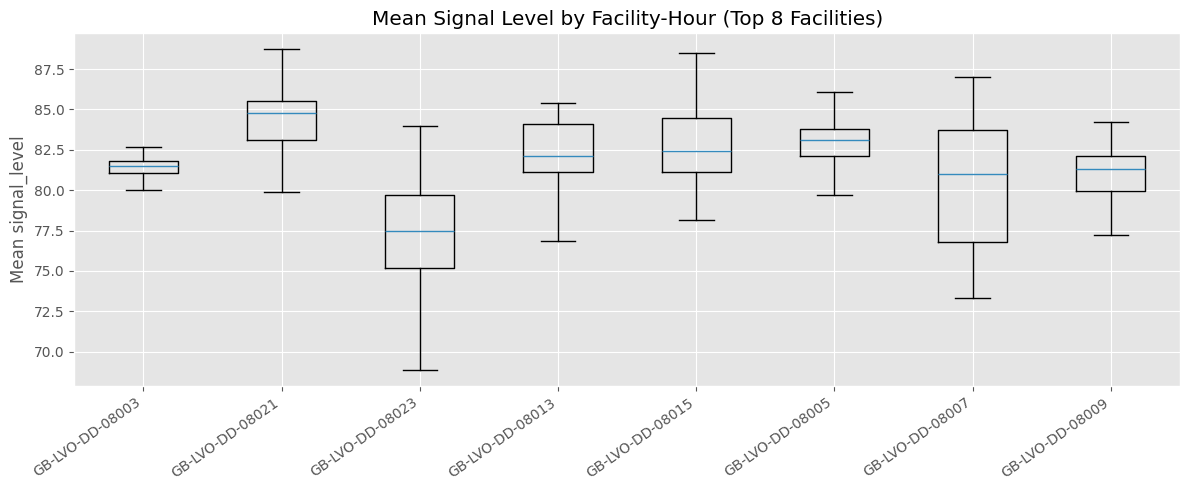

,facility_num,facility_name,avg_trusted_ratio,avg_local_ratio,avg_flagged_rate,avg_signal_level
6,66338.0,GB-LVO-DD-08019,0.024252,0.753878,0.247725,82.489317
3,66333.0,GB-LVO-DD-08009,0.008457,0.559136,0.230854,81.201842
8,66342.0,GB-LVO-DD-08023,0.043941,0.751704,0.131813,76.329820
7,66340.0,GB-LVO-DD-08021,0.011140,0.835102,0.103264,84.457675
2,66332.0,GB-LVO-DD-08007,0.030719,0.812844,0.102890,80.469060
5,66336.0,GB-LVO-DD-08015,0.024696,0.931094,0.036389,82.889515
1,66331.0,GB-LVO-DD-08005,0.005241,0.967818,0.021829,82.768619
0,66330.0,GB-LVO-DD-08003,0.004763,0.983139,0.010870,81.405655
4,66335.0,GB-LVO-DD-08013,0.003578,0.983017,0.007959,82.293098


In [33]:
# Signal distribution and quality by location
sig_box_order = (
    facility_hour_quality.groupby("facility_name", as_index=False)["total_sessions"].sum()
    .sort_values("total_sessions", ascending=False)["facility_name"]
    .head(8)
    .tolist()
)

series_signal = [
    facility_hour_quality.loc[facility_hour_quality["facility_name"] == nm, "mean_signal_level"]
    for nm in sig_box_order
]

plt.figure(figsize=(12, 5))
plt.boxplot(series_signal, labels=sig_box_order, showfliers=False)
plt.title("Mean Signal Level by Facility-Hour (Top 8 Facilities)")
plt.xticks(rotation=35, ha="right")
plt.ylabel("Mean signal_level")
plt.tight_layout()
plt.show()

quality_summary = (
    facility_hour_quality.groupby(["facility_num", "facility_name"], as_index=False)
    .agg(
        avg_trusted_ratio=("trusted_ratio", "mean"),
        avg_local_ratio=("local_ratio", "mean"),
        avg_flagged_rate=("flagged_rate", "mean"),
        avg_signal_level=("mean_signal_level", "mean"),
    )
    .sort_values("avg_flagged_rate", ascending=False)
)

display(quality_summary.head(10))

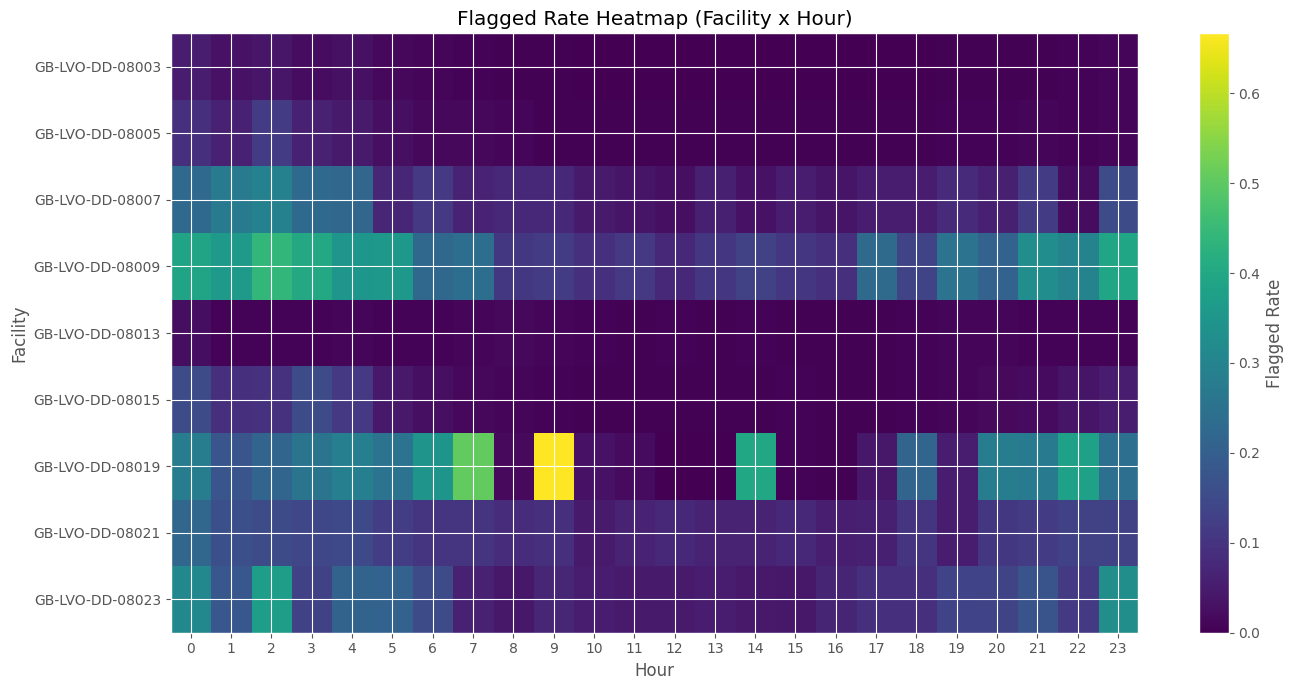

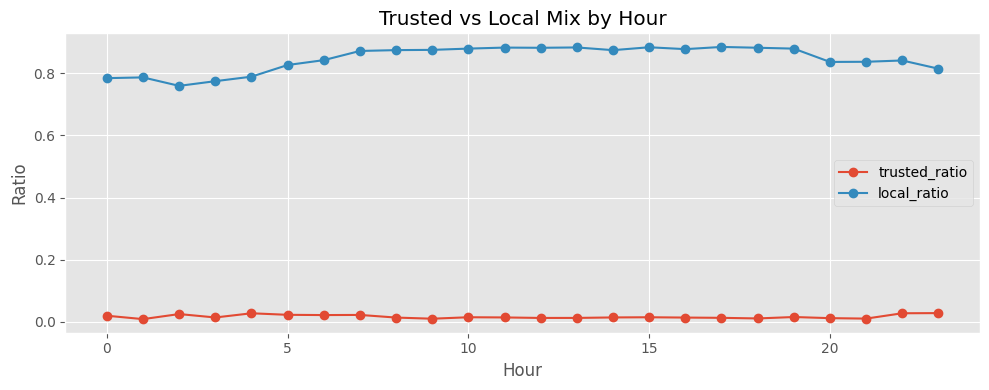

In [34]:
q = facility_hour_quality.copy()
q["hour"] = q["hour_start"].dt.hour

flag_heat = q.groupby(["facility_name", "hour"], as_index=False)["flagged_rate"].mean().pivot(
    index="facility_name", columns="hour", values="flagged_rate"
)

plt.figure(figsize=(14, 7))
plt.imshow(flag_heat.fillna(0).to_numpy(dtype=float), aspect="auto")
plt.title("Flagged Rate Heatmap (Facility x Hour)")
plt.xlabel("Hour")
plt.ylabel("Facility")
plt.xticks(range(24), range(24))
plt.yticks(range(len(flag_heat.index)), flag_heat.index)
plt.colorbar(label="Flagged Rate")
plt.tight_layout()
plt.show()

mix = q.groupby("hour", as_index=False).agg(
    trusted_ratio=("trusted_ratio", "mean"),
    local_ratio=("local_ratio", "mean"),
)

plt.figure(figsize=(10, 4))
plt.plot(mix["hour"], mix["trusted_ratio"], marker="o", label="trusted_ratio")
plt.plot(mix["hour"], mix["local_ratio"], marker="o", label="local_ratio")
plt.title("Trusted vs Local Mix by Hour")
plt.xlabel("Hour")
plt.ylabel("Ratio")
plt.legend()
plt.tight_layout()
plt.show()

## Anomaly Context EDA

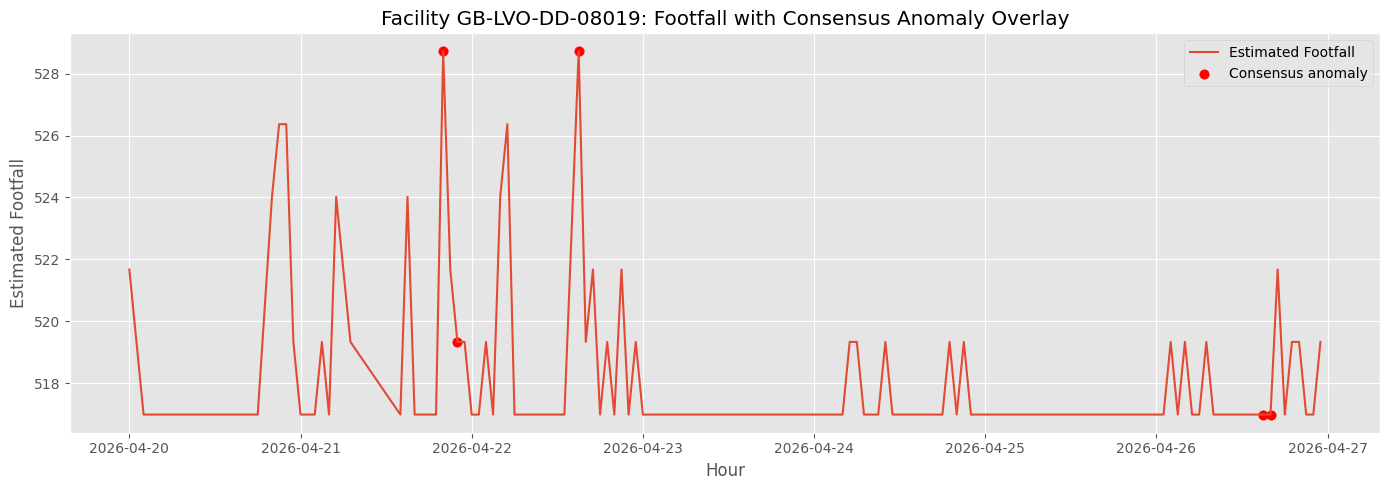

In [35]:
# Overlay consensus anomalies on facility baseline traffic
if len(anomaly_comparison_df):
    fac = int(anomaly_comparison_df.sort_values("ensemble_score", ascending=False).iloc[0]["facility_num"])
    fac_name = anomaly_comparison_df.loc[anomaly_comparison_df["facility_num"] == fac, "facility_name"].iloc[0]
    fac_ts = anomaly_comparison_df.loc[anomaly_comparison_df["facility_num"] == fac].sort_values("hour_start").copy()

    plt.figure(figsize=(14, 5))
    plt.plot(fac_ts["hour_start"], fac_ts["estimated_total_footfall"], label="Estimated Footfall")
    cons = fac_ts.loc[fac_ts["is_consensus_anomaly"]]
    plt.scatter(cons["hour_start"], cons["estimated_total_footfall"], s=45, color="red", label="Consensus anomaly")
    plt.title(f"Facility {fac_name}: Footfall with Consensus Anomaly Overlay")
    plt.xlabel("Hour")
    plt.ylabel("Estimated Footfall")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No rows found in anomaly_comparison_df.")

/var/folders/g_/1979vpb127z7y9jtbplxm61r0000gn/T/ipykernel_57005/2265352318.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ac.groupby("agreement_bucket", as_index=False)


,agreement_bucket,hour_count,mean_footfall,median_footfall,mean_ensemble_score
0,0 methods,1274,544.217206,526.37,0.160032
1,1 method,148,571.333041,533.42,0.254052
2,2 methods,16,594.656875,599.21,0.360423
3,3+ methods,13,666.080000,660.30,0.431715


/var/folders/g_/1979vpb127z7y9jtbplxm61r0000gn/T/ipykernel_57005/2265352318.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(series, labels=box_order, showfliers=False)


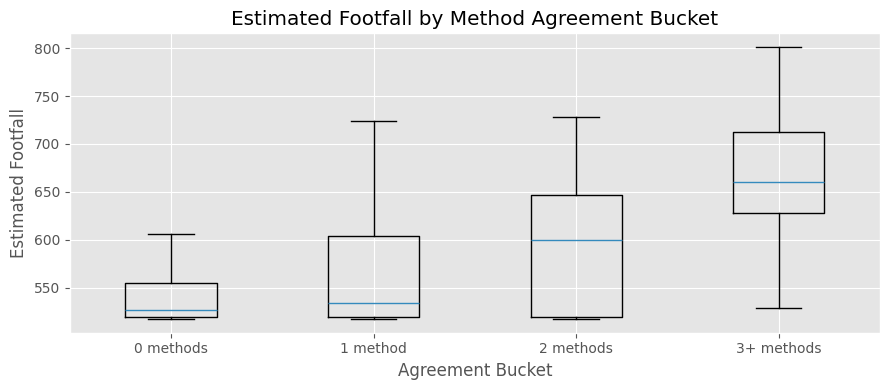

In [36]:
# Agreement level vs normal hours
ac = anomaly_comparison_df.copy()
ac["agreement_bucket"] = pd.cut(
    ac["method_agreement_count"],
    bins=[-0.1, 0.5, 1.5, 2.5, 10],
    labels=["0 methods", "1 method", "2 methods", "3+ methods"],
)

bucket_stats = (
    ac.groupby("agreement_bucket", as_index=False)
    .agg(
        hour_count=("hour_start", "size"),
        mean_footfall=("estimated_total_footfall", "mean"),
        median_footfall=("estimated_total_footfall", "median"),
        mean_ensemble_score=("ensemble_score", "mean"),
    )
)

display(bucket_stats)

box_order = ["0 methods", "1 method", "2 methods", "3+ methods"]
series = [ac.loc[ac["agreement_bucket"] == b, "estimated_total_footfall"] for b in box_order]
plt.figure(figsize=(9, 4))
plt.boxplot(series, labels=box_order, showfliers=False)
plt.title("Estimated Footfall by Method Agreement Bucket")
plt.xlabel("Agreement Bucket")
plt.ylabel("Estimated Footfall")
plt.tight_layout()
plt.show()

In [37]:
# Top anomaly windows with contextual features
context_cols = [
    "facility_num",
    "hour_start",
    "total_sessions",
    "unique_devices",
    "mean_signal_level",
    "median_session_duration",
    "trusted_ratio",
    "local_ratio",
    "flagged_rate",
]

context = anomaly_comparison_df.merge(
    facility_hour_quality[context_cols],
    on=["facility_num", "hour_start"],
    how="left",
)

top_context = context.sort_values("ensemble_score", ascending=False).head(25)

display(
    top_context[
        [
            "facility_name",
            "hour_start",
            "estimated_total_footfall",
            "ensemble_score",
            "method_agreement_count",
            "is_consensus_anomaly",
            "total_sessions",
            "unique_devices",
            "flagged_rate",
            "trusted_ratio",
            "local_ratio",
            "mean_signal_level",
        ]
    ]
)

print("Benchmark snapshot:")
display(benchmark_df[["method", "flagged_hours", "composite_score", "auc_contam", "auc_shock"]].sort_values("composite_score", ascending=False))

,facility_name,hour_start,estimated_total_footfall,ensemble_score,method_agreement_count,is_consensus_anomaly,total_sessions,unique_devices,flagged_rate,trusted_ratio,local_ratio,mean_signal_level
0,GB-LVO-DD-08019,2026-04-22 15:00:00+00:00,528.72,0.636828,4,True,159,159,0.012579,0.031447,0.955975,82.905660
1,GB-LVO-DD-08019,2026-04-21 20:00:00+00:00,528.72,0.531263,2,True,113,112,0.000000,0.044248,0.920354,81.513274
2,GB-LVO-DD-08009,2026-04-25 13:00:00+00:00,679.09,0.500749,2,True,5386,5375,0.000928,0.013182,0.997215,79.893984
3,GB-LVO-DD-08019,2026-04-20 21:00:00+00:00,526.37,0.494125,1,False,129,128,0.015504,0.031008,0.945736,80.868217
4,GB-LVO-DD-08021,2026-04-25 15:00:00+00:00,733.13,0.461760,3,True,10302,10259,0.001262,0.009124,0.995923,82.588429
5,GB-LVO-DD-08005,2026-04-26 17:00:00+00:00,627.40,0.458173,2,True,4309,4292,0.002553,0.011372,0.992574,86.356695
6,GB-LVO-DD-08021,2026-04-25 13:00:00+00:00,726.08,0.456496,3,True,11868,11836,0.001095,0.007752,0.995956,83.017947
7,GB-LVO-DD-08003,2026-04-23 16:00:00+00:00,672.04,0.455502,3,True,7237,7223,0.000553,0.009396,0.995993,81.105292
8,GB-LVO-DD-08005,2026-04-26 15:00:00+00:00,608.61,0.429023,3,True,4733,4720,0.001902,0.008663,0.993239,84.630678
9,GB-LVO-DD-08021,2026-04-25 14:00:00+00:00,711.99,0.425956,3,True,11626,11602,0.001032,0.007483,0.996990,82.555909


Benchmark snapshot:


,method,flagged_hours,composite_score,auc_contam,auc_shock
0,zscore,25,0.739436,0.506752,0.692698
1,isolation_forest,51,0.606087,0.507317,0.820999
2,stl_residual,51,0.525675,0.426778,0.563743
3,markov_hour,37,0.379732,0.065387,0.817862
4,matrix_profile,56,0.189200,0.498304,0.436577


## Executive Pattern Summary (Auto-generated)

In [38]:
# 8-12 concise findings for quick reporting
findings = []

total_devices = len(device_profile)
repeat_devices = int((device_profile["active_days"] >= 3).sum())
findings.append(f"- {repeat_devices:,}/{total_devices:,} devices appear on at least 3 days (repeat-presence cohort).")

multi_fac = int((device_profile["unique_facilities"] > 1).sum())
findings.append(f"- {multi_fac:,} devices are observed across multiple facilities, indicating measurable intra-mall movement.")

top_fac = facility_totals.iloc[0]
findings.append(f"- Top traffic location is {top_fac['facility_name']} with {top_fac['estimated_total_footfall']:.0f} estimated visits over 7 days.")

by_day = hourly_footfall.assign(date=hourly_footfall["hour_start"].dt.date).groupby("date", as_index=False)["estimated_total_footfall"].sum()
peak_day = by_day.sort_values("estimated_total_footfall", ascending=False).iloc[0]
low_day = by_day.sort_values("estimated_total_footfall", ascending=True).iloc[0]
findings.append(f"- Daily volume ranges from {low_day['estimated_total_footfall']:.0f} to {peak_day['estimated_total_footfall']:.0f}; peak day is {peak_day['date']}.")

peak_hour_global = hourly_footfall.assign(hour=hourly_footfall["hour_start"].dt.hour).groupby("hour", as_index=False)["estimated_total_footfall"].mean().sort_values("estimated_total_footfall", ascending=False).iloc[0]
findings.append(f"- Strongest global hour-of-day pattern peaks around {int(peak_hour_global['hour']):02d}:00 UTC.")

top_edge = transitions.sort_values("transition_count", ascending=False).iloc[0]
findings.append(f"- Dominant movement edge is {top_edge['facility_name_from']} -> {top_edge['facility_name_to']} ({int(top_edge['transition_count']):,} transitions).")

q_top_flag = quality_summary.sort_values("avg_flagged_rate", ascending=False).iloc[0]
findings.append(f"- Highest average flagged-rate location is {q_top_flag['facility_name']} ({q_top_flag['avg_flagged_rate']*100:.2f}% flagged sessions by hour).")

consensus_hours = int(anomaly_comparison_df["is_consensus_anomaly"].sum())
max_agreement = int(anomaly_comparison_df["method_agreement_count"].max())
findings.append(f"- Consensus anomaly windows: {consensus_hours} hours; maximum detector agreement reaches {max_agreement} methods.")

best_method = benchmark_df.sort_values("composite_score", ascending=False).iloc[0]
findings.append(f"- Best benchmarked detector (composite) is {best_method['method']} with score {best_method['composite_score']:.3f}.")

long_paths = top_paths.loc[top_paths["path_length"] >= 3, "device_count"].sum() if "path_length" in top_paths.columns else 0
short_paths = top_paths.loc[top_paths["path_length"] == 2, "device_count"].sum() if "path_length" in top_paths.columns else 0
if short_paths + long_paths > 0:
    findings.append(f"- Journey complexity skews short: path length=2 dominates vs longer paths (>=3) in top templates.")

for f in findings:
    print(f)

summary_findings_df = pd.DataFrame({"finding": findings})
summary_findings_df

- 2,856/2,043,833 devices appear on at least 3 days (repeat-presence cohort).
- 131,687 devices are observed across multiple facilities, indicating measurable intra-mall movement.
- Top traffic location is GB-LVO-DD-08015 with 97758 estimated visits over 7 days.
- Daily volume ranges from 110341 to 117622; peak day is 2026-04-26.
- Strongest global hour-of-day pattern peaks around 12:00 UTC.
- Dominant movement edge is GB-LVO-DD-08003 -> GB-LVO-DD-08005 (51,395 transitions).
- Highest average flagged-rate location is GB-LVO-DD-08019 (24.77% flagged sessions by hour).
- Consensus anomaly windows: 29 hours; maximum detector agreement reaches 4 methods.
- Best benchmarked detector (composite) is zscore with score 0.739.
- Journey complexity skews short: path length=2 dominates vs longer paths (>=3) in top templates.


,finding
0,"- 2,856/2,043,833 devices appear on at least 3..."
1,"- 131,687 devices are observed across multiple..."
2,- Top traffic location is GB-LVO-DD-08015 with...
3,- Daily volume ranges from 110341 to 117622; p...
4,- Strongest global hour-of-day pattern peaks a...
5,- Dominant movement edge is GB-LVO-DD-08003 ->...
6,- Highest average flagged-rate location is GB-...
7,- Consensus anomaly windows: 29 hours; maximum...
8,- Best benchmarked detector (composite) is zsc...
9,- Journey complexity skews short: path length=...


## Notes

- If running for the first time in fast mode, the notebook may still build `eda_*` aggregate caches if they are missing.
- For repeatable and quick reruns, keep `BUILD_RAW_EDA_AGGREGATES = False`.
- This notebook is intentionally exploratory and complements the modeling notebook (`technical_assignment_analysis.ipynb`).